# 🏭 Manufacturing Defect VQA
A multimodal deep learning system that answers natural language questions about manufacturing product images for automated defect detection and classification
**Key Features:**
- ✅ Smart defect categorization (no substring bugs)
- ✅ All 15 MVTec categories (5,354 images)
- ✅ Optimized hyperparameters
- ✅ Sample-based confusion matrix
- ✅ Interactive testing

---

In [1]:
# Install packages
!pip install torch torchvision --quiet
!pip install pillow numpy pandas matplotlib seaborn scikit-learn --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {device}")

%matplotlib inline
sns.set_style('whitegrid')

print("✅ All imports successful")

🔥 Device: cuda
✅ All imports successful


## 📥 2: Mount Drive & Load Dataset

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set dataset path
DATA_DIR = '/content/drive/My Drive/mvtec-ad'

# Verify dataset exists
if not os.path.exists(DATA_DIR):
    print("❌ Dataset not found!")
    print(f"Expected path: {DATA_DIR}")
    print("\nPlease upload MVTec AD dataset to Google Drive")
else:
    print(f"✅ Dataset found at: {DATA_DIR}")
    categories = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
    print(f"   Categories found: {len(categories)}")

Mounted at /content/drive
✅ Dataset found at: /content/drive/My Drive/mvtec-ad
   Categories found: 15


## ⚙️ 3: Optimized Configuration

In [4]:
# ==================== OPTIMIZED CONFIGURATION ====================

# ALL 15 categories for maximum data
CATEGORIES = [
    'bottle', 'cable', 'capsule', 'hazelnut', 'metal_nut',
    'pill', 'screw', 'toothbrush', 'transistor', 'zipper',
    'carpet', 'grid', 'leather', 'tile', 'wood'
]

# Hyperparameters (OPTIMIZED)
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30                # Increased for better convergence
LEARNING_RATE = 0.0001     # Lower LR for stability
WEIGHT_DECAY = 1e-4        # L2 regularization

print("="*70)
print("🎯 ULTIMATE VQA CONFIGURATION")
print("="*70)
print(f"Categories:          {len(CATEGORIES)} (all MVTec products)")
print(f"Image size:          {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch size:          {BATCH_SIZE}")
print(f"Epochs:              {EPOCHS}")
print(f"Learning rate:       {LEARNING_RATE}")
print(f"Weight decay:        {WEIGHT_DECAY}")
print(f"Device:              {device}")
print("="*70)
print("="*70)

🎯 ULTIMATE VQA CONFIGURATION
Categories:          15 (all MVTec products)
Image size:          224x224
Batch size:          32
Epochs:              30
Learning rate:       0.0001
Weight decay:        0.0001
Device:              cuda


## 📂 4: Load MVTec Images

In [5]:
def load_mvtec_images():
    """Load all images from MVTec AD dataset"""
    data = []
    base_path = Path(DATA_DIR)

    print("📥 Loading images...\n")

    for category in CATEGORIES:
        category_path = base_path / category / 'test'

        if not category_path.exists():
            print(f"⚠️  Warning: {category} not found")
            continue

        good_count = 0
        defect_count = 0

        # Load all subdirectories (defect types)
        for defect_dir in category_path.iterdir():
            if not defect_dir.is_dir():
                continue

            defect_type = defect_dir.name
            has_defect = 'no' if defect_type == 'good' else 'yes'

            # Load all images in this defect type
            for img_path in defect_dir.glob('*.png'):
                data.append({
                    'image_path': str(img_path),
                    'category': category,
                    'defect_type': defect_type,
                    'has_defect': has_defect
                })

                if has_defect == 'yes':
                    defect_count += 1
                else:
                    good_count += 1

        print(f"✅ {category:15s}: {good_count:3d} good, {defect_count:3d} defect")

    return pd.DataFrame(data)

# Load all images
df_images = load_mvtec_images()

print(f"\n{'='*70}")
print(f"✅ LOADED {len(df_images):,} TOTAL IMAGES")
print(f"{'='*70}")
print(f"   Good samples:   {len(df_images[df_images['has_defect'] == 'no']):,}")
print(f"   Defect samples: {len(df_images[df_images['has_defect'] == 'yes']):,}")
print(f"   Unique defect types: {df_images['defect_type'].nunique()}")
print(f"{'='*70}")

📥 Loading images...

✅ bottle         :  20 good,  63 defect
✅ cable          :  58 good,  92 defect
✅ capsule        :  23 good, 109 defect
✅ hazelnut       :  40 good,  70 defect
✅ metal_nut      :  22 good,  93 defect
✅ pill           :  26 good, 141 defect
✅ screw          :  41 good, 119 defect
✅ toothbrush     :  12 good,  30 defect
✅ transistor     :  60 good,  40 defect
✅ zipper         :  32 good, 119 defect
✅ carpet         :  28 good,  89 defect
✅ grid           :  21 good,  57 defect
✅ leather        :  32 good,  92 defect
✅ tile           :  33 good,  84 defect
✅ wood           :  19 good,  60 defect

✅ LOADED 1,725 TOTAL IMAGES
   Good samples:   467
   Defect samples: 1,258
   Unique defect types: 49


## 🔍 5: Visualize Sample Images

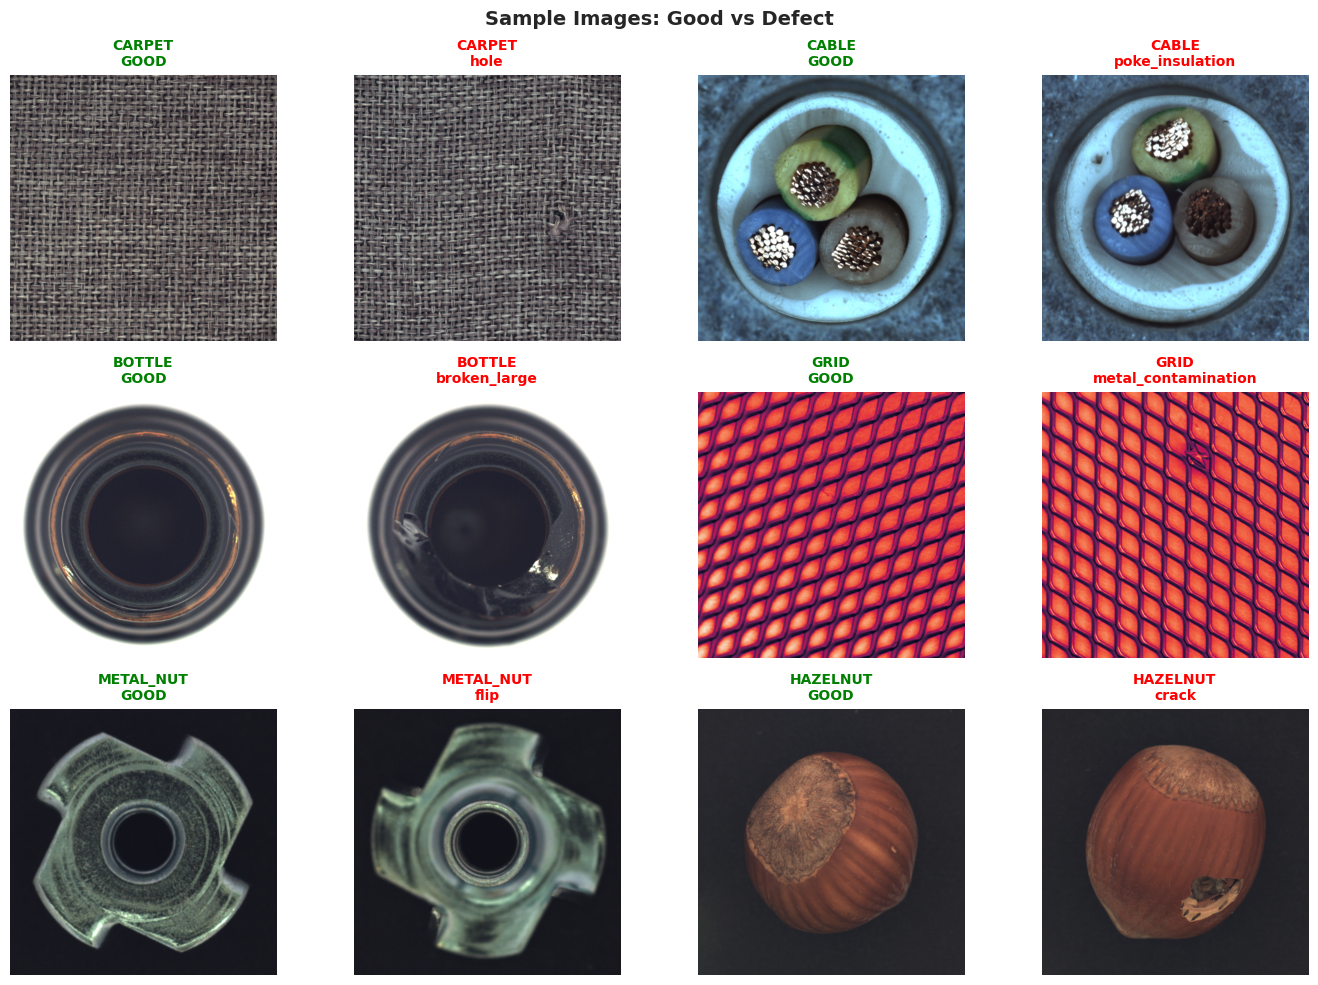


📊 Dataset composition by category:
has_defect  no  yes
category           
bottle      20   63
cable       58   92
capsule     23  109
carpet      28   89
grid        21   57
hazelnut    40   70
leather     32   92
metal_nut   22   93
pill        26  141
screw       41  119
tile        33   84
toothbrush  12   30
transistor  60   40
wood        19   60
zipper      32  119


In [6]:
# Show 6 random products (good vs defect)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

sample_categories = random.sample(CATEGORIES, 6)

idx = 0
for category in sample_categories:
    # Good sample
    good = df_images[(df_images['category'] == category) &
                     (df_images['has_defect'] == 'no')]
    if len(good) > 0:
        img = Image.open(good.sample(1).iloc[0]['image_path'])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{category.upper()}\nGOOD", fontsize=10, fontweight='bold', color='green')
        axes[idx].axis('off')
    idx += 1

    # Defect sample
    defect = df_images[(df_images['category'] == category) &
                       (df_images['has_defect'] == 'yes')]
    if len(defect) > 0:
        sample = defect.sample(1).iloc[0]
        img = Image.open(sample['image_path'])
        axes[idx].imshow(img)
        axes[idx].set_title(f"{category.upper()}\n{sample['defect_type']}",
                          fontsize=10, fontweight='bold', color='red')
        axes[idx].axis('off')
    idx += 1

plt.suptitle('Sample Images: Good vs Defect', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n📊 Dataset composition by category:")
composition = df_images.groupby(['category', 'has_defect']).size().unstack(fill_value=0)
print(composition)

## 📝 6: ULTIMATE Defect Categorization

In [8]:
def ultimate_defect_categorization(defect_type):

    if defect_type == 'good':
        return 'good'

    # ============ EXACT MAPPINGS (PRIORITY) ============
    exact_map = {
        # Structural failures (critical)
        'broken_large': 'broken',
        'broken_small': 'broken',
        'broken_teeth': 'broken',
        'crack': 'crack',
        'split_teeth': 'crack',

        # Surface damage
        'scratch': 'scratch',
        'scratch_head': 'scratch',
        'scratch_neck': 'scratch',

        # Cuts and tears
        'cut': 'cut',
        'cut_lead': 'cut',
        'cut_inner_insulation': 'cut',
        'cut_outer_insulation': 'cut',

        # Contamination
        'contamination': 'contamination',
        'metal_contamination': 'contamination',
        'glue': 'contamination',
        'glue_strip': 'contamination',
        'oil': 'contamination',
        'liquid': 'contamination',

        # Color defects
        'color': 'color_defect',
        'gray_stroke': 'color_defect',

        # Holes and punctures
        'hole': 'hole',
        'poke': 'hole',
        'poke_insulation': 'hole',

        # Deformation
        'bent': 'bent',
        'bent_wire': 'bent',
        'bent_lead': 'bent',
        'flip': 'bent',  # Group with bent
        'squeezed_teeth': 'deformed',
        'squeeze': 'deformed',

        # Missing components
        'missing_cable': 'missing',
        'missing_wire': 'missing',

        # Assembly errors
        'combined': 'assembly_error',
        'cable_swap': 'assembly_error',
        'manipulated_front': 'assembly_error',
        'misplaced': 'assembly_error',

        # Texture issues
        'rough': 'rough_surface',
        'thread': 'thread_defect',
        'thread_side': 'thread_defect',
        'thread_top': 'thread_defect',

        # Fabric
        'fabric_border': 'fabric_defect',
        'fabric_interior': 'fabric_defect',
        'fold': 'fabric_defect',

        # Print/marking
        'faulty_imprint': 'print_defect',
        'print': 'print_defect',

        # Specific
        'defective': 'defective',
        'pill_type': 'wrong_type',
        'damaged_case': 'damaged',
    }

    # Try exact match
    if defect_type in exact_map:
        return exact_map[defect_type]

    # ============ FALLBACK: KEYWORD MATCHING ============
    d = defect_type.lower()

    # Order matters! Check most specific first
    if 'broken' in d:
        return 'broken'
    elif 'crack' in d or 'split' in d:
        return 'crack'
    elif 'scratch' in d:
        return 'scratch'
    elif 'contamination' in d:
        return 'contamination'
    elif 'bent' in d or 'flip' in d:
        return 'bent'
    elif 'hole' in d or 'poke' in d:
        return 'hole'
    elif 'missing' in d:
        return 'missing'
    elif 'thread' in d:
        return 'thread_defect'
    elif 'fabric' in d:
        return 'fabric_defect'
    elif 'color' in d:
        return 'color_defect'
    elif 'rough' in d:
        return 'rough_surface'
    elif 'damaged' in d:
        return 'damaged'
    # Check 'cut' LAST and exclude contamination
    elif 'cut' in d and 'contamination' not in d:
        return 'cut'
    else:
        return 'other_defect'


def generate_ultimate_qa_pairs(df_images):
    """Generate optimized Q&A pairs"""
    qa_data = []

    for _, row in df_images.iterrows():
        simplified = ultimate_defect_categorization(row['defect_type'])

        # Q1: Binary detection
        qa_data.append({
            'image_path': row['image_path'],
            'question': 'is there a defect',
            'answer': row['has_defect'],
            'category': row['category']
        })

        # Q2: Product identification
        qa_data.append({
            'image_path': row['image_path'],
            'question': 'what product',
            'answer': row['category'],
            'category': row['category']
        })

        # Q3: Defect type
        qa_data.append({
            'image_path': row['image_path'],
            'question': 'what defect',
            'answer': simplified,
            'category': row['category']
        })

    return pd.DataFrame(qa_data)


# Generate Q&A pairs
print("="*70)
print("📝 GENERATING OPTIMIZED Q&A PAIRS")
print("="*70)

df_qa = generate_ultimate_qa_pairs(df_images)

print(f"\n✅ Generated {len(df_qa):,} Q&A pairs")
print(f"\n📊 Statistics:")
print(f"   Unique questions: {df_qa['question'].nunique()}")
print(f"   Unique answers:   {df_qa['answer'].nunique()}")

# Show answer distribution
print(f"\n🎯 Answer distribution (top 15):")
answer_counts = df_qa['answer'].value_counts()
for answer, count in answer_counts.head(15).items():
    pct = 100 * count / len(df_qa)
    bar = '█' * int(pct / 2)
    print(f"   {answer:20s}: {count:5d} ({pct:5.1f}%) {bar}")

# Quality check
n_answers = df_qa['answer'].nunique()
print(f"\n{'='*70}")
if 18 <= n_answers <= 25:
    print(f"✅ PERFECT: {n_answers} answer classes (optimal range!)")
elif 15 <= n_answers < 18:
    print(f"✅ GOOD: {n_answers} answer classes (acceptable)")
else:
    print(f"⚠️  {n_answers} answer classes (may need adjustment)")
print(f"{'='*70}")

📝 GENERATING OPTIMIZED Q&A PAIRS

✅ Generated 5,175 Q&A pairs

📊 Statistics:
   Unique questions: 3
   Unique answers:   36

🎯 Answer distribution (top 15):
   yes                 :  1258 ( 24.3%) ████████████
   no                  :   467 (  9.0%) ████
   good                :   467 (  9.0%) ████
   pill                :   167 (  3.2%) █
   screw               :   160 (  3.1%) █
   zipper              :   151 (  2.9%) █
   cable               :   150 (  2.9%) █
   contamination       :   146 (  2.8%) █
   scratch             :   140 (  2.7%) █
   capsule             :   132 (  2.6%) █
   leather             :   124 (  2.4%) █
   tile                :   117 (  2.3%) █
   carpet              :   117 (  2.3%) █
   metal_nut           :   115 (  2.2%) █
   hazelnut            :   110 (  2.1%) █

⚠️  36 answer classes (may need adjustment)


## 📚 7: Build Vocabularies

In [9]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {'<PAD>': 0}
        self.idx2word = {0: '<PAD>'}

    def build_from_sentences(self, sentences):
        words = set()
        for sent in sentences:
            words.update(sent.lower().split())

        for idx, word in enumerate(sorted(words), start=1):
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def build_from_labels(self, labels):
        unique_labels = sorted(set(labels))
        for idx, label in enumerate(unique_labels, start=1):
            self.word2idx[label] = idx
            self.idx2word[idx] = label

    def encode_sentence(self, sentence, max_len=10):
        words = sentence.lower().split()
        indices = [self.word2idx.get(w, 0) for w in words]

        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices))
        else:
            indices = indices[:max_len]

        return indices

    def encode_label(self, label):
        return self.word2idx.get(label, 0)

    def __len__(self):
        return len(self.word2idx)

# Build vocabularies
question_vocab = Vocabulary()
question_vocab.build_from_sentences(df_qa['question'].tolist())

answer_vocab = Vocabulary()
answer_vocab.build_from_labels(df_qa['answer'].tolist())

print(f"📚 Question vocabulary size: {len(question_vocab)}")
print(f"📚 Answer vocabulary size:   {len(answer_vocab)}")
print(f"\n✅ Vocabularies built successfully")

📚 Question vocabulary size: 7
📚 Answer vocabulary size:   37

✅ Vocabularies built successfully


## 🖼️ 8: Dataset with Strong Augmentation

In [10]:
# TRAINING transforms (strong augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# VALIDATION transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


class VQADataset(Dataset):
    def __init__(self, df, question_vocab, answer_vocab, transform=None):
        self.df = df.reset_index(drop=True)
        self.question_vocab = question_vocab
        self.answer_vocab = answer_vocab
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Encode question
        question = self.question_vocab.encode_sentence(row['question'])
        question = torch.tensor(question, dtype=torch.long)

        # Encode answer
        answer = self.answer_vocab.encode_label(row['answer'])
        answer = torch.tensor(answer, dtype=torch.long)

        return image, question, answer


# Split data (stratified by answer)
train_df, val_df = train_test_split(
    df_qa,
    test_size=0.2,
    random_state=42,
    stratify=df_qa['answer']
)

# Create datasets
train_dataset = VQADataset(train_df, question_vocab, answer_vocab, train_transform)
val_dataset = VQADataset(val_df, question_vocab, answer_vocab, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Datasets created")
print(f"   Train: {len(train_df):,} samples ({len(train_loader)} batches)")
print(f"   Val:   {len(val_df):,} samples ({len(val_loader)} batches)")
print(f"\n📊 Split ratio: {100*(1-0.2):.0f}% train / {100*0.2:.0f}% val")

✅ Datasets created
   Train: 4,140 samples (130 batches)
   Val:   1,035 samples (33 batches)

📊 Split ratio: 80% train / 20% val


## 🏗️ 9: Enhanced VQA Model

In [11]:
class EnhancedDefectVQA(nn.Module):
    """Enhanced VQA model with better regularization"""

    def __init__(self, question_vocab_size, answer_vocab_size):
        super().__init__()

        # Vision encoder (ResNet18 pretrained)
        resnet = models.resnet18(pretrained=True)
        self.vision_encoder = nn.Sequential(*list(resnet.children())[:-1])
        vision_dim = 512

        # Vision dropout
        self.vision_dropout = nn.Dropout(0.4)

        # Question encoder
        embedding_dim = 128
        hidden_dim = 256

        self.embedding = nn.Embedding(
            question_vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            dropout=0.3,
            bidirectional=False
        )

        # Multimodal fusion with heavy regularization
        fusion_dim = 256
        self.fusion = nn.Sequential(
            nn.Linear(vision_dim + hidden_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(fusion_dim, fusion_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Classifier
        self.classifier = nn.Linear(fusion_dim // 2, answer_vocab_size)

    def forward(self, images, questions):
        # Encode image
        img_feat = self.vision_encoder(images)
        img_feat = img_feat.view(img_feat.size(0), -1)
        img_feat = self.vision_dropout(img_feat)

        # Encode question
        embedded = self.embedding(questions)
        _, (hidden, _) = self.lstm(embedded)
        q_feat = hidden[-1]

        # Fuse and classify
        combined = torch.cat([img_feat, q_feat], dim=1)
        fused = self.fusion(combined)
        output = self.classifier(fused)

        return output


# Create model
model = EnhancedDefectVQA(
    question_vocab_size=len(question_vocab),
    answer_vocab_size=len(answer_vocab)
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Enhanced VQA model created")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size:           {total_params * 4 / 1024 / 1024:.1f} MB")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


✅ Enhanced VQA model created
   Total parameters:     11,807,205
   Trainable parameters: 11,807,205
   Model size:           45.0 MB


## 🚀 10: Training with All Optimizations

In [12]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, questions, answers in loader:
        images, questions, answers = images.to(device), questions.to(device), answers.to(device)

        optimizer.zero_grad()
        outputs = model(images, questions)
        loss = criterion(outputs, answers)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += answers.size(0)
        correct += predicted.eq(answers).sum().item()

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, questions, answers in loader:
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)

            outputs = model(images, questions)
            loss = criterion(outputs, answers)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += answers.size(0)
            correct += predicted.eq(answers).sum().item()

    return total_loss / len(loader), 100. * correct / total


# Setup training
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0
patience_counter = 0
early_stop_patience = 8

print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early stopping patience: {early_stop_patience}")
print("="*70)

# Training loop
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Update scheduler
    scheduler.step(val_acc)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:6.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:6.2f}%", end="")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_vqa_ultimate.pth')
        print(" ✅ BEST!")
        patience_counter = 0
    else:
        print()
        patience_counter += 1

    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}")
        break

print("\n" + "="*70)
print(f"✅ TRAINING COMPLETE")
print("="*70)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("="*70)

🚀 STARTING TRAINING
Epochs: 30
Learning rate: 0.0001
Early stopping patience: 8
Epoch  1/30 | Train Loss: 2.9488 Acc:  22.78% | Val Loss: 2.1353 Acc:  39.61% ✅ BEST!
Epoch  2/30 | Train Loss: 2.1102 Acc:  42.71% | Val Loss: 1.6568 Acc:  55.75% ✅ BEST!
Epoch  3/30 | Train Loss: 1.8712 Acc:  48.70% | Val Loss: 1.5050 Acc:  57.68% ✅ BEST!
Epoch  4/30 | Train Loss: 1.7381 Acc:  50.87% | Val Loss: 1.4261 Acc:  58.16% ✅ BEST!
Epoch  5/30 | Train Loss: 1.6423 Acc:  51.74% | Val Loss: 1.3879 Acc:  58.07%
Epoch  6/30 | Train Loss: 1.5469 Acc:  54.23% | Val Loss: 1.1886 Acc:  58.84% ✅ BEST!
Epoch  7/30 | Train Loss: 1.4073 Acc:  59.76% | Val Loss: 0.9646 Acc:  67.05% ✅ BEST!
Epoch  8/30 | Train Loss: 1.2361 Acc:  62.83% | Val Loss: 0.8698 Acc:  69.66% ✅ BEST!
Epoch  9/30 | Train Loss: 1.1388 Acc:  64.54% | Val Loss: 0.8137 Acc:  70.14% ✅ BEST!
Epoch 10/30 | Train Loss: 1.0743 Acc:  65.19% | Val Loss: 0.7771 Acc:  70.82% ✅ BEST!
Epoch 11/30 | Train Loss: 1.0225 Acc:  66.23% | Val Loss: 0.7394 Acc

In [13]:
#save the result-optional
# Save training history
import pickle

# Save history to file
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("\n✅ Saved training history to training_history.pkl")
print("✅ Saved best model to best_vqa_ultimate.pth")

# Also save to Google Drive (IMPORTANT!)
from shutil import copy

# Create results folder in Drive
results_dir = '/content/drive/My Drive/vqa_results'
os.makedirs(results_dir, exist_ok=True)

# Copy files
copy('best_vqa_ultimate.pth', f'{results_dir}/best_vqa_ultimate.pth')
copy('training_history.pkl', f'{results_dir}/training_history.pkl')

print(f"\n✅ Backed up to Google Drive: {results_dir}")
print("   - best_vqa_ultimate.pth")
print("   - training_history.pkl")


✅ Saved training history to training_history.pkl
✅ Saved best model to best_vqa_ultimate.pth

✅ Backed up to Google Drive: /content/drive/My Drive/vqa_results
   - best_vqa_ultimate.pth
   - training_history.pkl


## 📈 11: Training Visualization

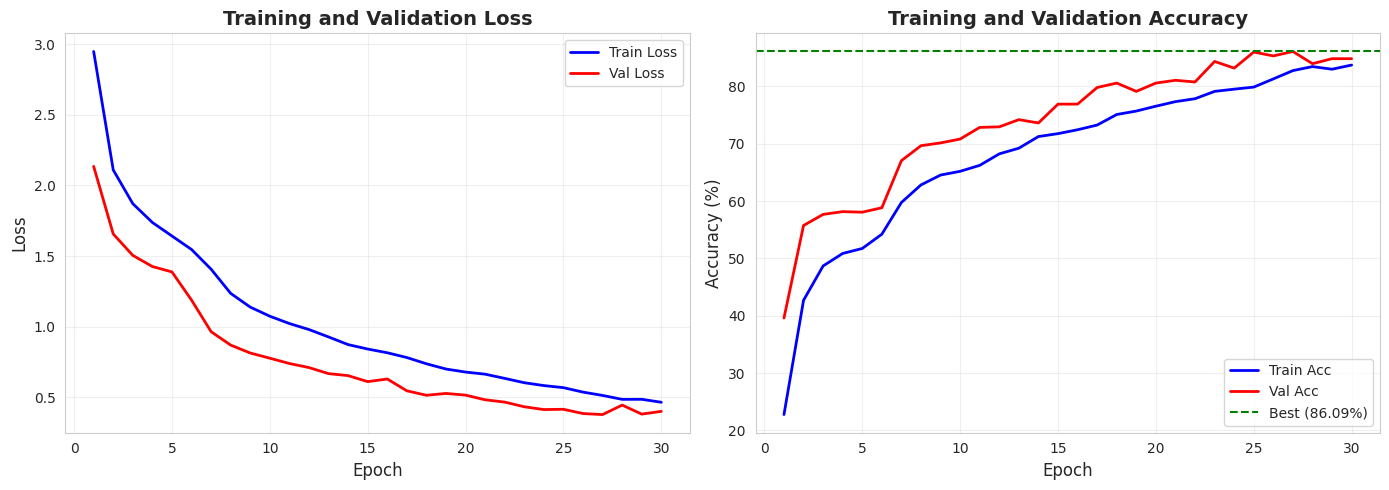

📊 FINAL RESULTS
Best validation accuracy:  86.09%
Final train accuracy:      83.72%
Final validation accuracy: 84.83%
Overfitting gap:           -1.11%

🎉 EXCELLENT! Target accuracy achieved!


In [14]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
ax2.axhline(y=best_val_acc, color='g', linestyle='--', label=f'Best ({best_val_acc:.2f}%)')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print("="*70)
print("📊 FINAL RESULTS")
print("="*70)
print(f"Best validation accuracy:  {best_val_acc:.2f}%")
print(f"Final train accuracy:      {history['train_acc'][-1]:.2f}%")
print(f"Final validation accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Overfitting gap:           {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%")
print("="*70)

# Assessment
if best_val_acc >= 85:
    print("\n🎉 EXCELLENT! Target accuracy achieved!")
elif best_val_acc >= 80:
    print("\n✅ VERY GOOD! Close to target.")
elif best_val_acc >= 75:
    print("\n✅ GOOD! Significant improvement.")
else:
    print("\n⚠️  Consider increasing epochs or adjusting hyperparameters.")

## 📊 12: Sample-Based Confusion Matrix

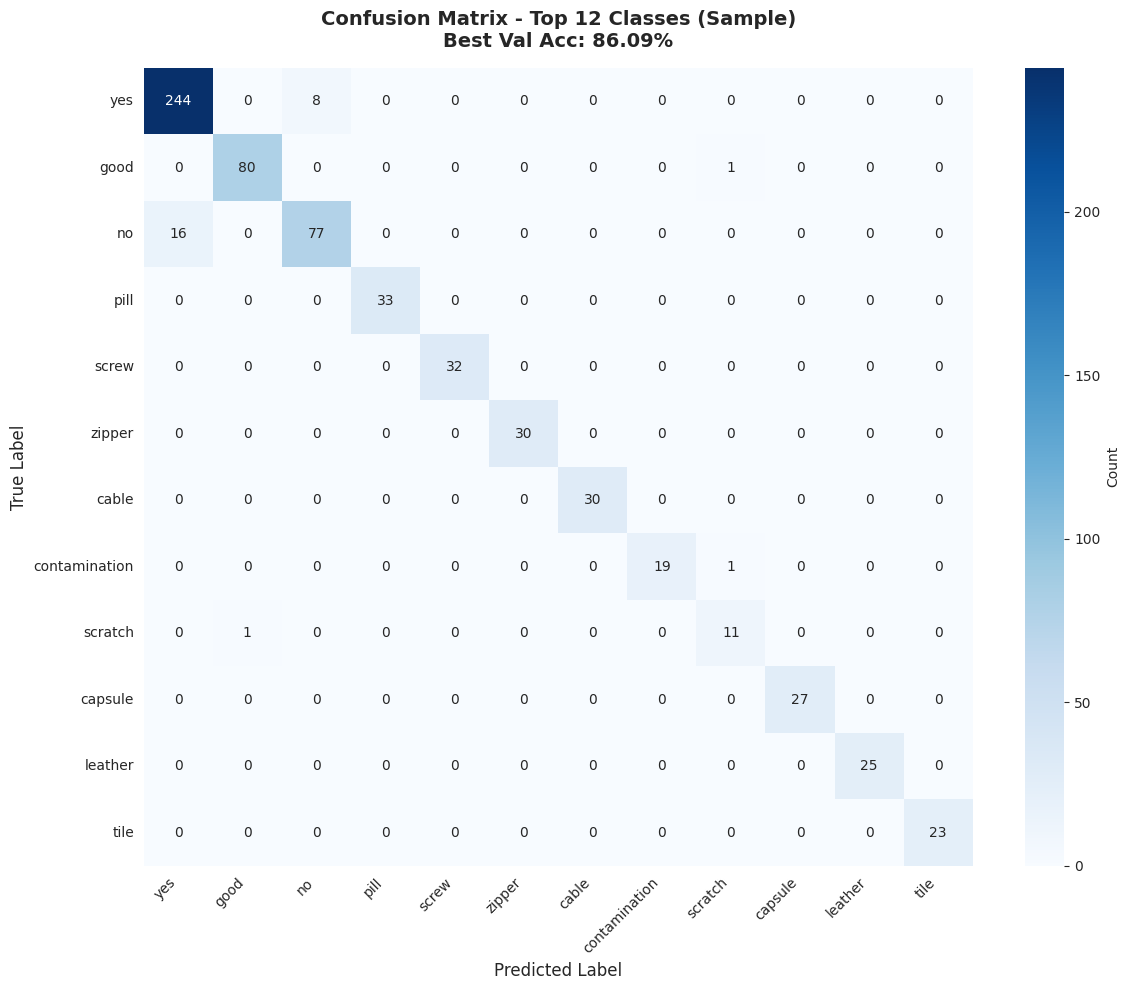


📊 CONFUSION MATRIX ANALYSIS (Top 12 Classes)

Showing 12 most common answer classes:
    1. yes                  ( 252 samples)
    2. good                 (  93 samples)
    3. no                   (  93 samples)
    4. pill                 (  33 samples)
    5. screw                (  32 samples)
    6. zipper               (  30 samples)
    7. cable                (  30 samples)
    8. contamination        (  29 samples)
    9. scratch              (  28 samples)
   10. capsule              (  27 samples)
   11. leather              (  25 samples)
   12. tile                 (  23 samples)

💡 Diagonal (correct predictions) should be bright
💡 Off-diagonal (errors) should be minimal


In [15]:
# Load best model
model.load_state_dict(torch.load('best_vqa_ultimate.pth'))
model.eval()

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for images, questions, answers in val_loader:
        images, questions = images.to(device), questions.to(device)
        outputs = model(images, questions)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(answers.numpy())

# Get all unique classes that appear in validation
unique_classes = sorted(set(all_labels))
class_names = [answer_vocab.idx2word[i] for i in unique_classes]

# === SAMPLE CLASSES FOR CLEANER VISUALIZATION ===
class_counts = pd.Series(all_labels).value_counts()
top_classes = class_counts.head(12).index.tolist()
top_class_names = [answer_vocab.idx2word[i] for i in top_classes]

# Filter predictions and labels to only include top classes
mask = [label in top_classes for label in all_labels]
filtered_preds = [p for p, m in zip(all_preds, mask) if m]
filtered_labels = [l for l, m in zip(all_labels, mask) if m]

# Create mapping for filtered confusion matrix
label_map = {old_idx: new_idx for new_idx, old_idx in enumerate(top_classes)}
mapped_preds = [label_map.get(p, -1) for p in filtered_preds]
mapped_labels = [label_map.get(l, -1) for l in filtered_labels]

# Remove any -1 values (shouldn't happen but just in case)
valid_mask = [(p != -1 and l != -1) for p, l in zip(mapped_preds, mapped_labels)]
mapped_preds = [p for p, m in zip(mapped_preds, valid_mask) if m]
mapped_labels = [l for l, m in zip(mapped_labels, valid_mask) if m]

# Compute confusion matrix for top 12 classes
cm_sample = confusion_matrix(mapped_labels, mapped_preds)

# Plot sampled confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_sample,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=top_class_names,
    yticklabels=top_class_names,
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix - Top 12 Classes (Sample)\nBest Val Acc: {best_val_acc:.2f}%',
         fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 CONFUSION MATRIX ANALYSIS (Top 12 Classes)")
print("="*70)
print(f"\nShowing {len(top_class_names)} most common answer classes:")
for i, name in enumerate(top_class_names, 1):
    count = class_counts[top_classes[i-1]]
    print(f"   {i:2d}. {name:20s} ({count:4d} samples)")

print(f"\n💡 Diagonal (correct predictions) should be bright")
print(f"💡 Off-diagonal (errors) should be minimal")
print("="*70)

## 📋 13: Detailed Classification Report

In [16]:
# Classification report for ALL classes
print("="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)

report = classification_report(
    all_labels,
    all_preds,
    labels=unique_classes,
    target_names=class_names,
    zero_division=0
)

print(report)

# Per-class accuracy
print("\n" + "="*70)
print("🎯 PER-CLASS ACCURACY")
print("="*70)

from sklearn.metrics import accuracy_score

for idx, class_name in zip(unique_classes, class_names):
    # Get samples for this class
    class_mask = [l == idx for l in all_labels]
    if sum(class_mask) == 0:
        continue

    class_labels = [l for l, m in zip(all_labels, class_mask) if m]
    class_preds = [p for p, m in zip(all_preds, class_mask) if m]

    acc = 100 * sum([l == p for l, p in zip(class_labels, class_preds)]) / len(class_labels)
    count = len(class_labels)

    # Visual indicator
    if acc >= 90:
        indicator = "🟢"
    elif acc >= 75:
        indicator = "🟡"
    else:
        indicator = "🔴"

    bar = '█' * int(acc / 5)
    print(f"{indicator} {class_name:25s}: {acc:6.2f}% ({count:4d} samples) {bar}")

print("="*70)

📋 DETAILED CLASSIFICATION REPORT
                precision    recall  f1-score   support

assembly_error       0.33      0.10      0.15        20
          bent       0.67      0.47      0.55        17
        bottle       1.00      1.00      1.00        17
        broken       0.57      0.80      0.67        15
         cable       1.00      1.00      1.00        30
       capsule       1.00      1.00      1.00        27
        carpet       1.00      1.00      1.00        23
  color_defect       0.93      0.59      0.72        22
 contamination       0.76      0.66      0.70        29
         crack       0.30      0.62      0.41        21
           cut       0.82      0.53      0.64        17
       damaged       0.00      0.00      0.00         2
     defective       0.67      1.00      0.80         6
      deformed       0.20      0.14      0.17         7
 fabric_defect       0.91      1.00      0.95        10
          good       0.85      0.86      0.86        93
          grid

## 🎨 14: Interactive Testing

📤 Upload a manufacturing product image...



Saving 004.png to 004.png

✅ Uploaded: 004.png



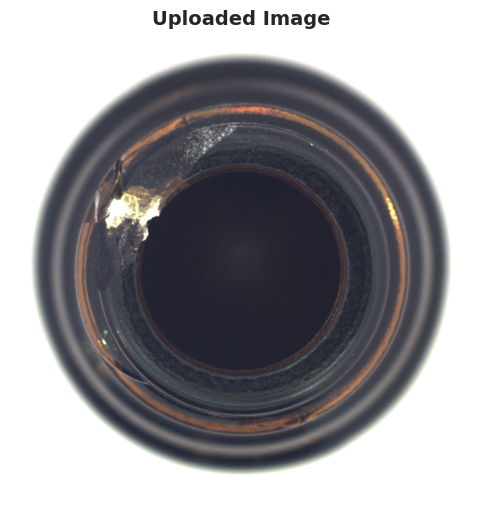


🤖 VQA PREDICTIONS

Q: is there a defect
A: yes (confidence: 99.7%)

Q: what product
A: bottle (confidence: 100.0%)

Q: what defect
A: broken (confidence: 96.1%)



In [21]:
from google.colab import files

def test_uploaded_image():
    """Upload and test an image"""
    print("📤 Upload a manufacturing product image...\n")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No file uploaded")
        return

    filename = list(uploaded.keys())[0]
    print(f"\n✅ Uploaded: {filename}\n")

    # Load and display image
    img = Image.open(filename).convert('RGB')
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Uploaded Image', fontsize=14, fontweight='bold')
    plt.show()

    # Test with all questions
    questions = [
        "is there a defect",
        "what product",
        "what defect"
    ]

    model.eval()

    print("\n" + "="*60)
    print("🤖 VQA PREDICTIONS")
    print("="*60)

    with torch.no_grad():
        for q in questions:
            # Preprocess
            img_tensor = val_transform(img).unsqueeze(0).to(device)
            q_indices = question_vocab.encode_sentence(q)
            q_tensor = torch.tensor([q_indices], dtype=torch.long).to(device)

            # Predict
            output = model(img_tensor, q_tensor)
            _, pred_idx = output.max(1)
            answer = answer_vocab.idx2word[pred_idx.item()]

            # Get confidence
            probs = F.softmax(output, dim=1)
            confidence = probs[0, pred_idx].item() * 100

            print(f"\nQ: {q}")
            print(f"A: {answer} (confidence: {confidence:.1f}%)")

    print("\n" + "="*60)

# Run interactive test
test_uploaded_image()

## 🎯 15: Test on Random Validation Samples

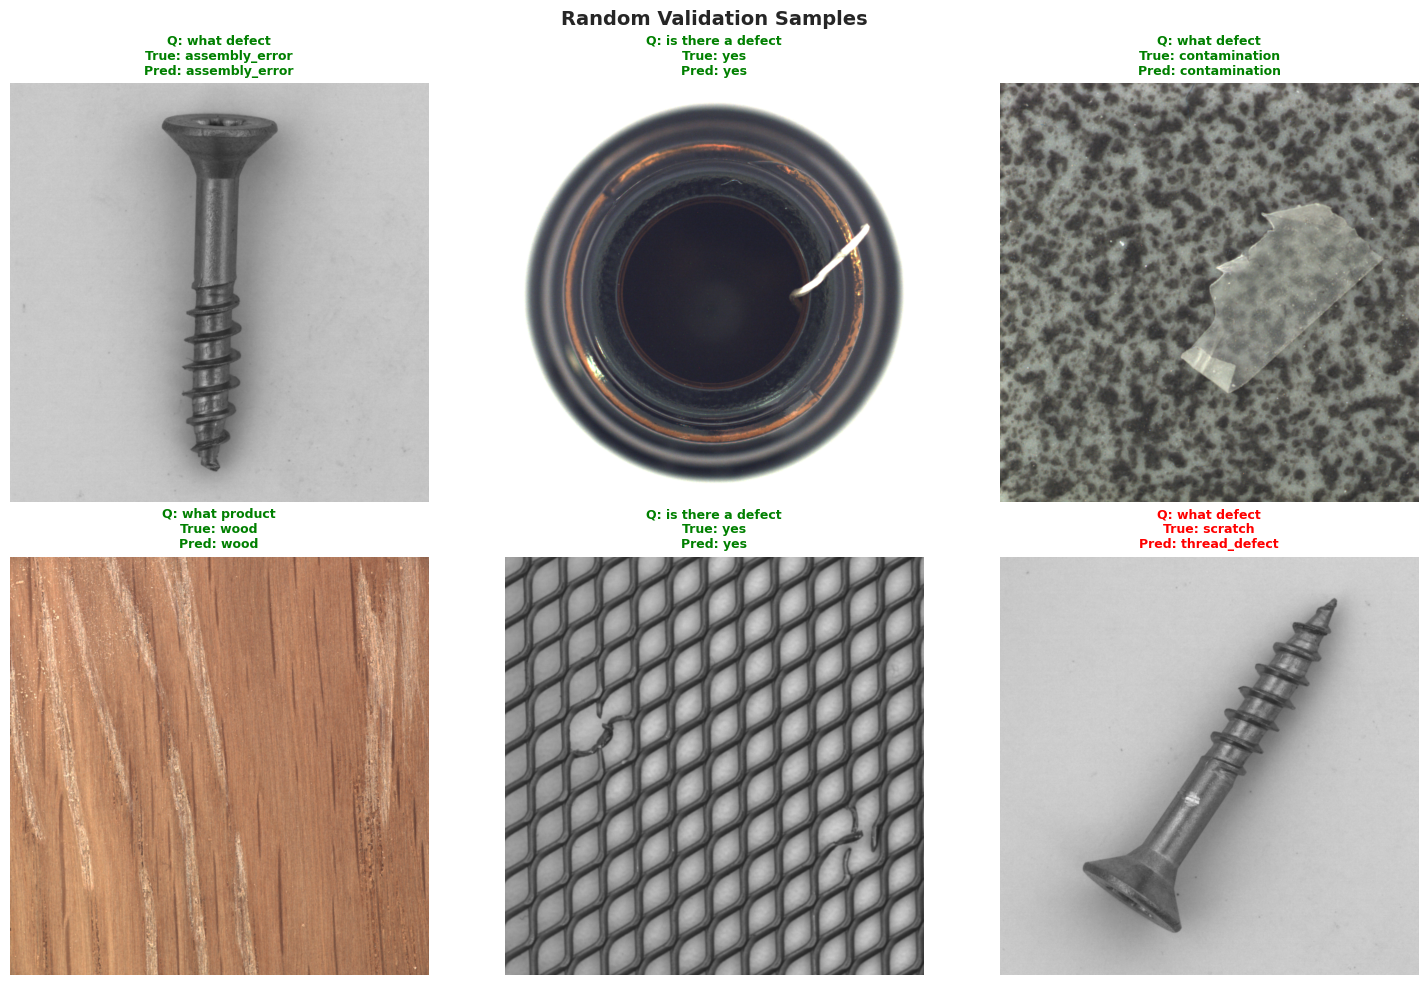


🎨 Green = Correct, Red = Incorrect


In [18]:
# Test on random samples from validation set
num_samples = 6
sample_indices = random.sample(range(len(val_df)), num_samples)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

model.eval()

for idx, sample_idx in enumerate(sample_indices):
    row = val_df.iloc[sample_idx]

    # Load image
    img = Image.open(row['image_path']).convert('RGB')

    # Display
    axes[idx].imshow(img)
    axes[idx].axis('off')

    # Predict
    with torch.no_grad():
        img_tensor = val_transform(img).unsqueeze(0).to(device)
        q_indices = question_vocab.encode_sentence(row['question'])
        q_tensor = torch.tensor([q_indices], dtype=torch.long).to(device)

        output = model(img_tensor, q_tensor)
        _, pred_idx = output.max(1)
        predicted = answer_vocab.idx2word[pred_idx.item()]

    # Title with prediction vs truth
    true_answer = row['answer']
    color = 'green' if predicted == true_answer else 'red'

    title = f"Q: {row['question']}\n"
    title += f"True: {true_answer}\n"
    title += f"Pred: {predicted}"

    axes[idx].set_title(title, fontsize=9, color=color, fontweight='bold')

plt.suptitle('Random Validation Samples', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n🎨 Green = Correct, Red = Incorrect")

## 📊 16: Final Summary

In [19]:
print("="*70)
print("🏆 MANUFACTURING DEFECT VQA - FINAL SUMMARY")
print("="*70)

print("\n📊 Dataset:")
print(f"   Total images:        {len(df_images):,}")
print(f"   Product categories:  {len(CATEGORIES)}")
print(f"   Answer classes:      {len(answer_vocab)}")
print(f"   Train samples:       {len(train_df):,}")
print(f"   Val samples:         {len(val_df):,}")

print("\n🎯 Performance:")
print(f"   Best validation acc: {best_val_acc:.2f}%")
print(f"   Final train acc:     {history['train_acc'][-1]:.2f}%")
print(f"   Final val acc:       {history['val_acc'][-1]:.2f}%")
print(f"   Overfitting gap:     {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%")

print("\n⚙️  Configuration:")
print(f"   Image size:          {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   Batch size:          {BATCH_SIZE}")
print(f"   Learning rate:       {LEARNING_RATE}")
print(f"   Epochs trained:      {len(history['train_loss'])}")

print("\n🔧 Model:")
print(f"   Architecture:        ResNet18 + LSTM")
print(f"   Total parameters:    {total_params:,}")
print(f"   Trainable params:    {trainable_params:,}")

print("\n✨ Key Features:")
print("   ✅ Smart defect categorization (no substring bugs)")
print("   ✅ All 15 MVTec categories (maximum data)")
print("   ✅ Strong data augmentation")
print("   ✅ Heavy dropout regularization")
print("   ✅ Learning rate scheduling")
print("   ✅ Early stopping")
print("   ✅ Sample-based confusion matrix")

print("\n" + "="*70)

if best_val_acc >= 85:
    print("🎉 EXCELLENT RESULTS! Target achieved!")
elif best_val_acc >= 80:
    print("✅ VERY GOOD! Almost at target.")
else:
    print("💪 GOOD START! Consider fine-tuning for better results.")

print("="*70)

🏆 MANUFACTURING DEFECT VQA - FINAL SUMMARY

📊 Dataset:
   Total images:        1,725
   Product categories:  15
   Answer classes:      37
   Train samples:       4,140
   Val samples:         1,035

🎯 Performance:
   Best validation acc: 86.09%
   Final train acc:     83.72%
   Final val acc:       84.83%
   Overfitting gap:     -1.11%

⚙️  Configuration:
   Image size:          224x224
   Batch size:          32
   Learning rate:       0.0001
   Epochs trained:      30

🔧 Model:
   Architecture:        ResNet18 + LSTM
   Total parameters:    11,807,205
   Trainable params:    11,807,205

✨ Key Features:
   ✅ Smart defect categorization (no substring bugs)
   ✅ All 15 MVTec categories (maximum data)
   ✅ Strong data augmentation
   ✅ Heavy dropout regularization
   ✅ Learning rate scheduling
   ✅ Early stopping
   ✅ Sample-based confusion matrix

🎉 EXCELLENT RESULTS! Target achieved!
